<a href="https://colab.research.google.com/github/rkalshs/bigdataprac2603041/blob/main/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

%config InlineBackend.figure_format='retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 42.1 MB/s eta 0:00:00


In [2]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 28.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=965dd0e79f8dbb5351728b2c00a1ef076d3af381c467888acd4cdf95a4c6cc08
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [3]:
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [4]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [6]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)


In [9]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [37]:
display_side_by_side(iris.head(), iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [17]:
display_series_side_by_side(iris['Petal.Length'][:5], iris.Species.value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [19]:
display_side_by_side(iris['Petal.Length'][:5].to_frame(), iris.Species.value_counts().to_frame())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [20]:
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


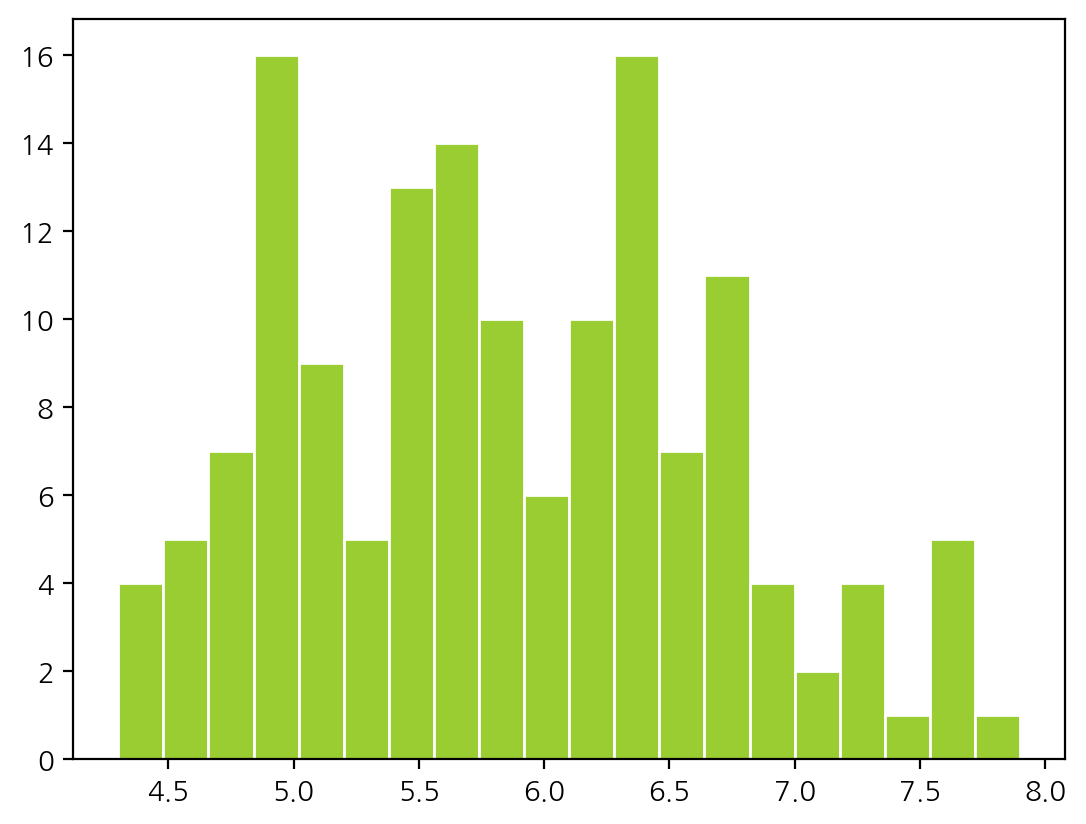

In [22]:
import matplotlib.pyplot as plt
n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20, color='yellowgreen', edgecolor='white')

print(n)
print(bins)
print(patches)

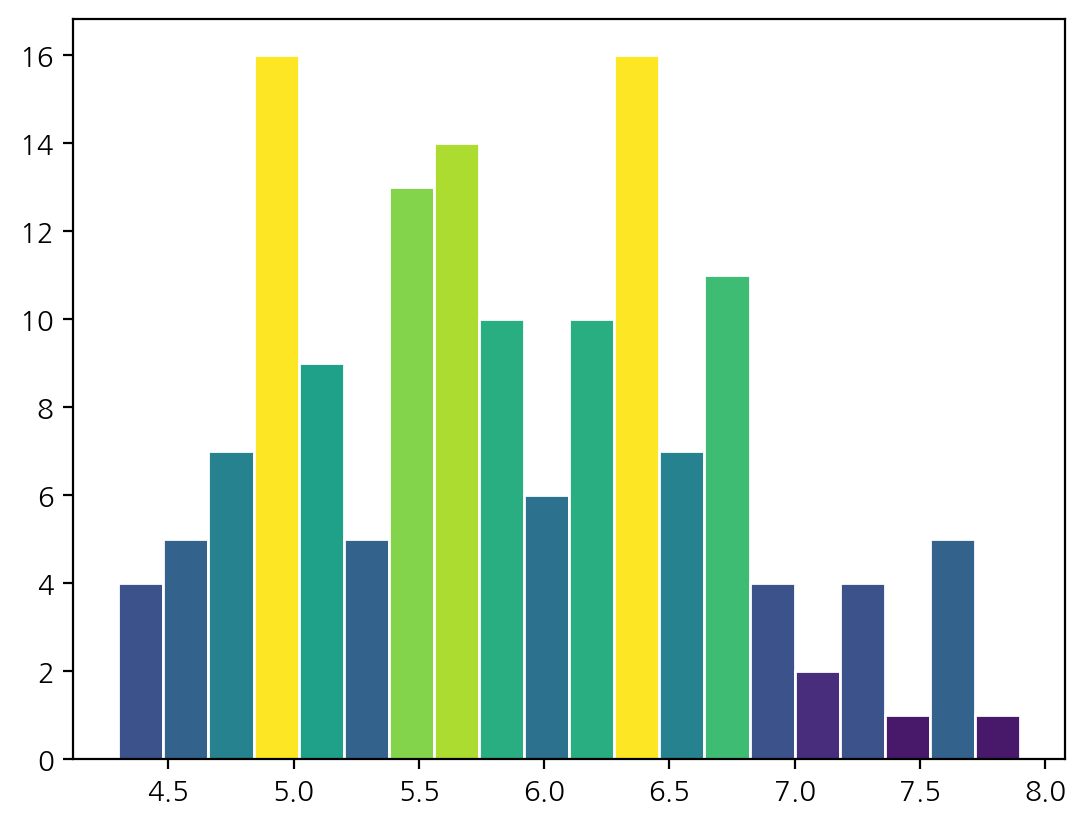

In [25]:
n, bins, patches = plt.hist(iris['Sepal.Length'], bins= 20, color='yellowgreen', edgecolor='white')

for i in range (len(patches)):
  patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))

plt.show()

<Axes: ylabel='Density'>

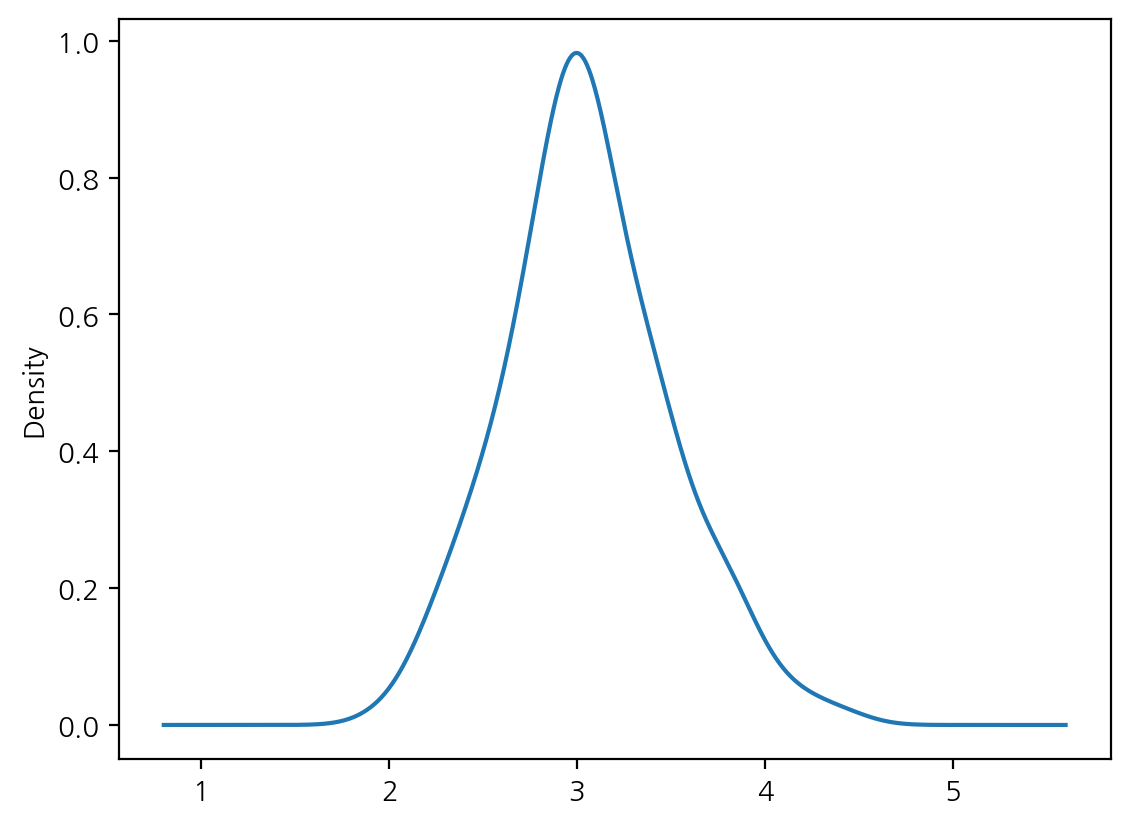

In [26]:
iris['Sepal.Width'].plot.density()


<Axes: ylabel='Density'>

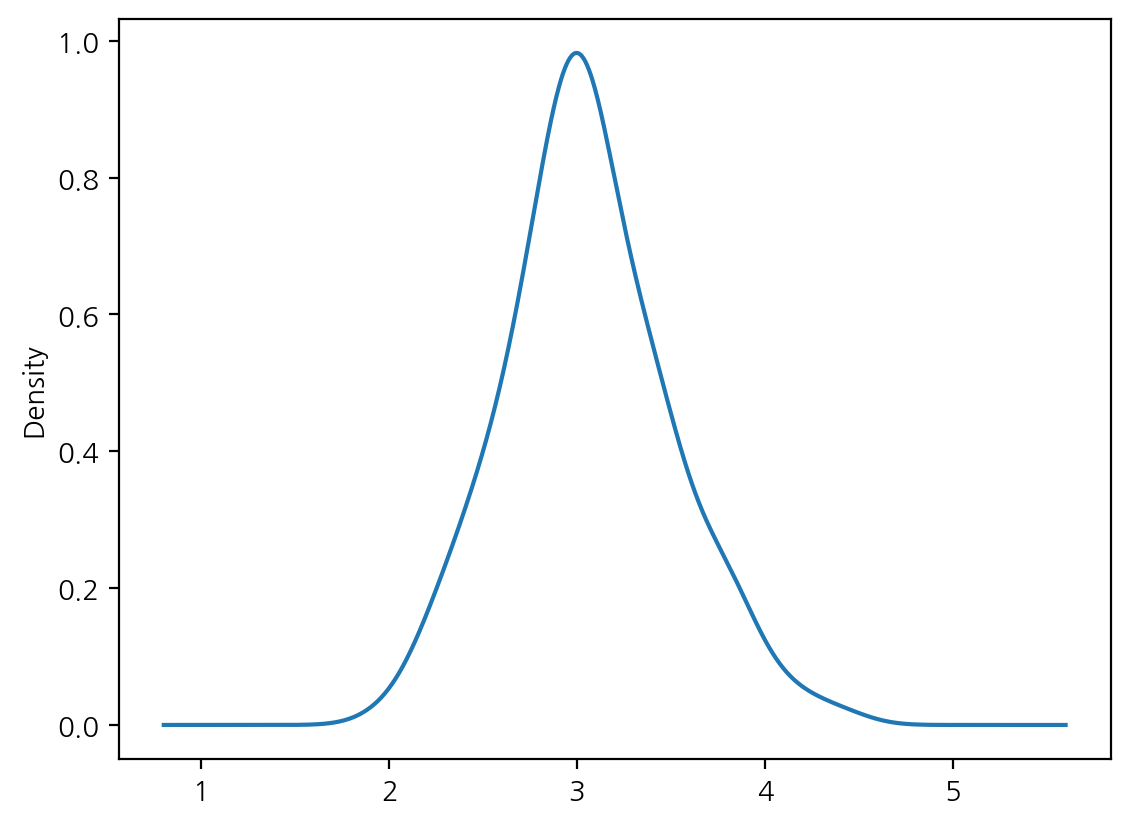

In [27]:
iris['Sepal.Width'].plot.kde()

In [28]:
plt.rcParams['figure.figsize'] = [5, 3]

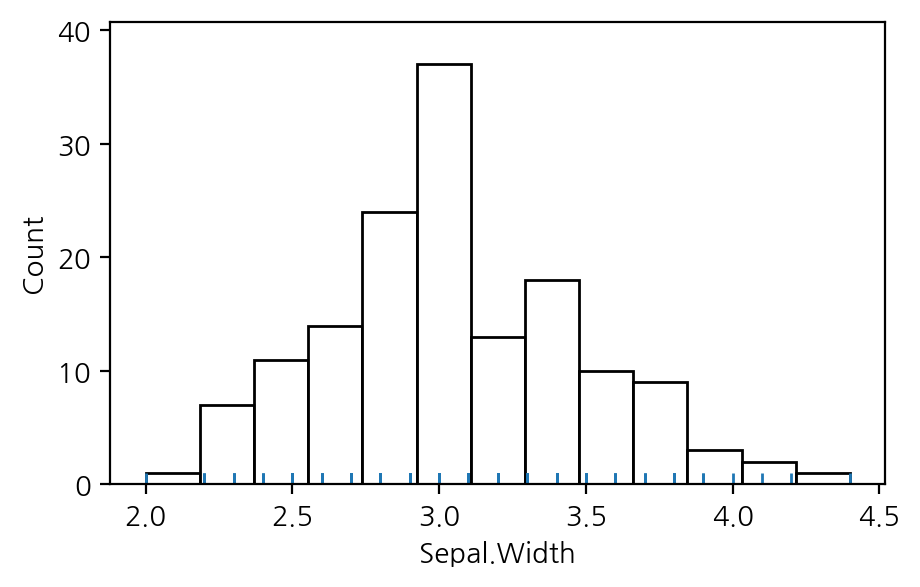

In [29]:
import seaborn as sns
sns.histplot(data = iris, x = iris['Sepal.Width'], color= 'white')
sns.rugplot(data=iris, x = iris['Sepal.Width']);

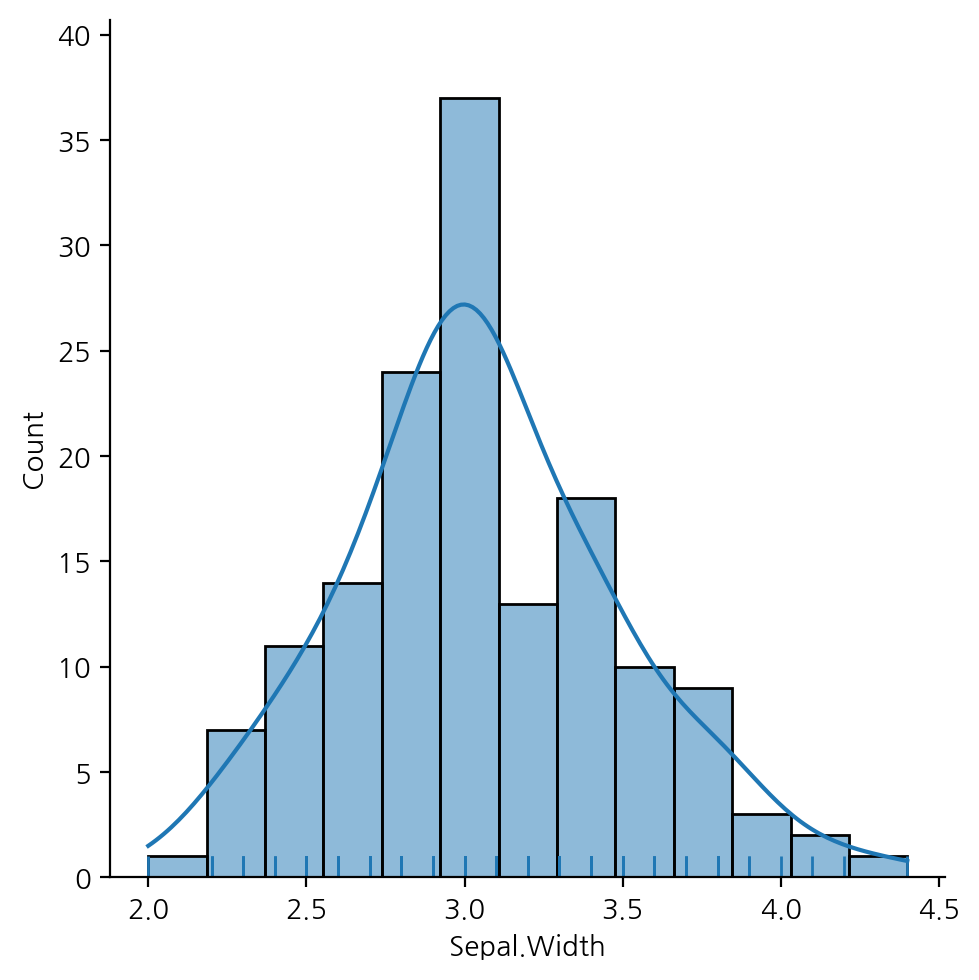

In [31]:
import seaborn as sns
sns.displot(data = iris['Sepal.Width'], kde=True, rug=True);

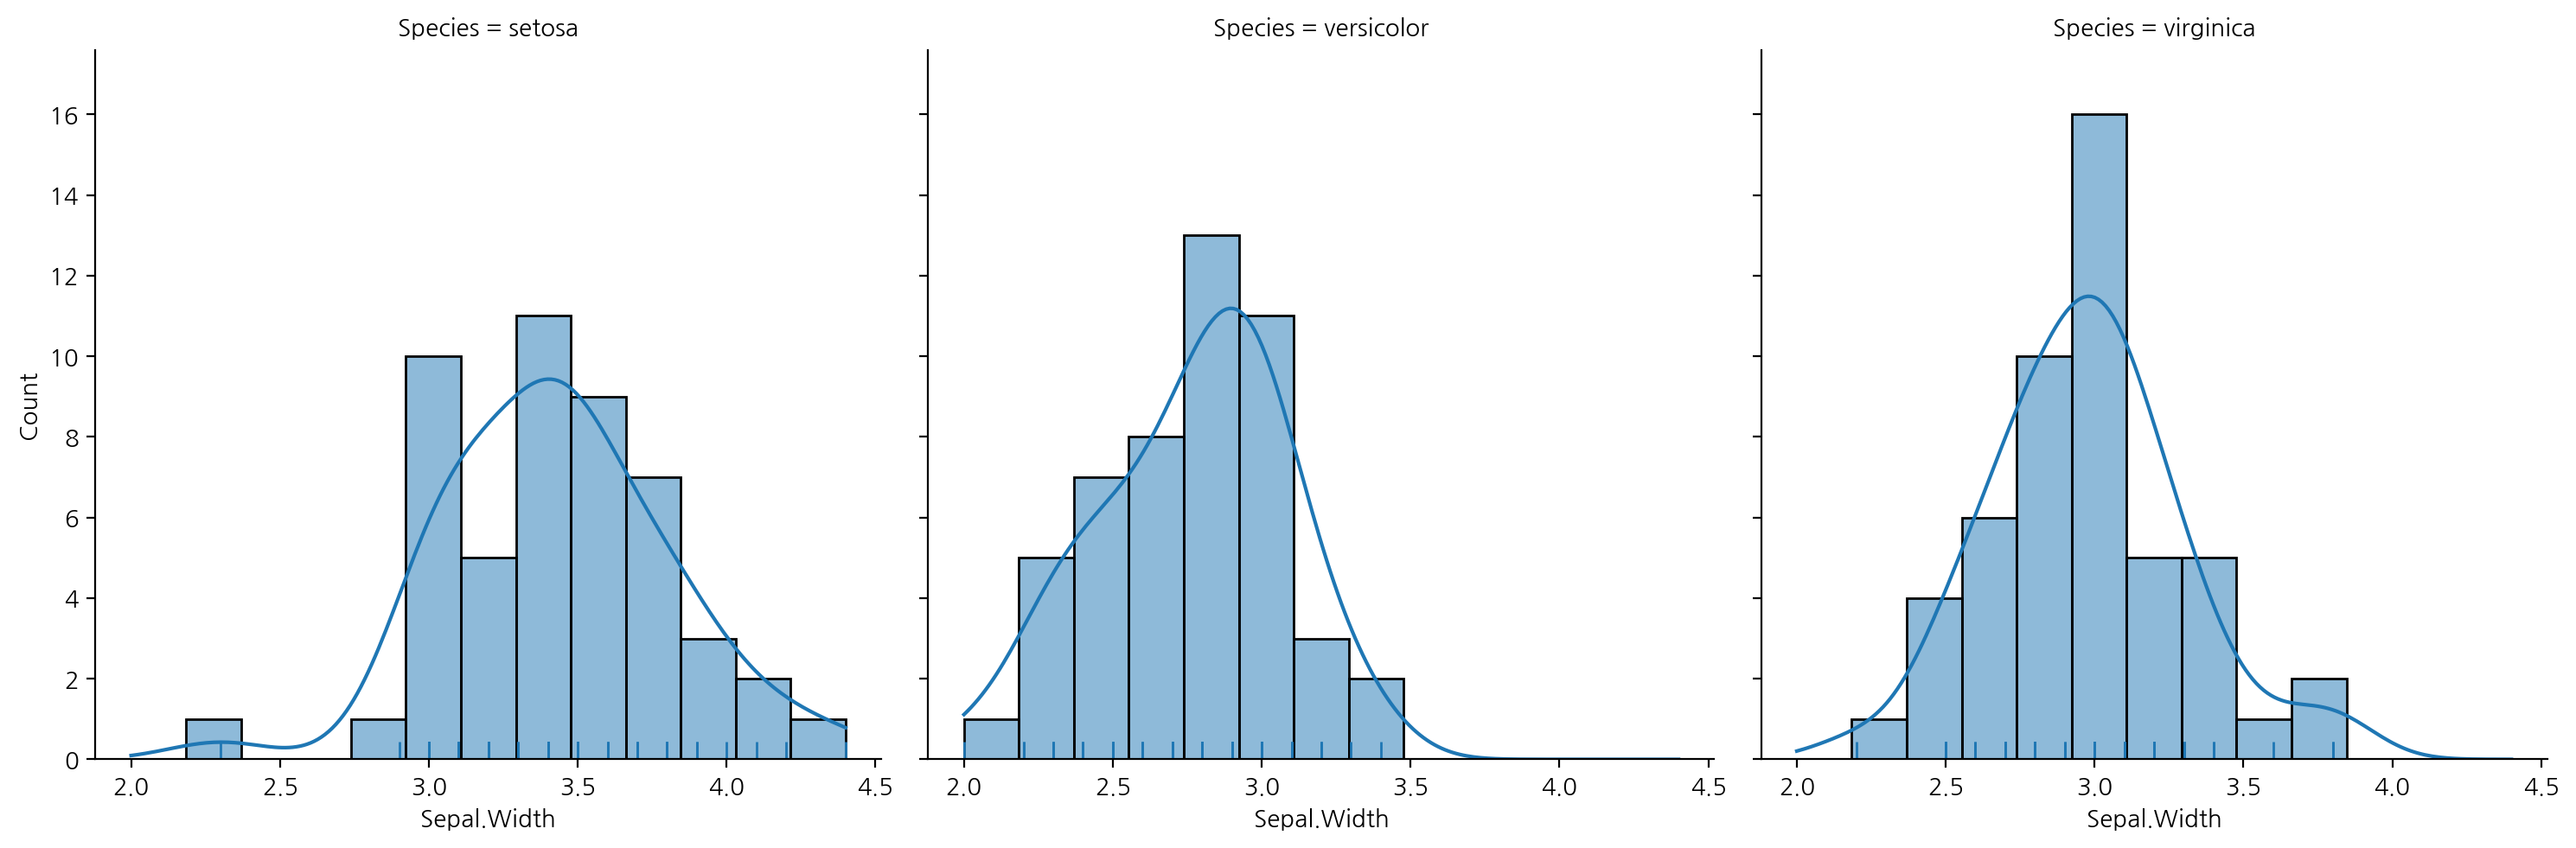

In [33]:
sns.displot(data = iris,  x = iris['Sepal.Width'], col = "Species", kde=True, rug=True);

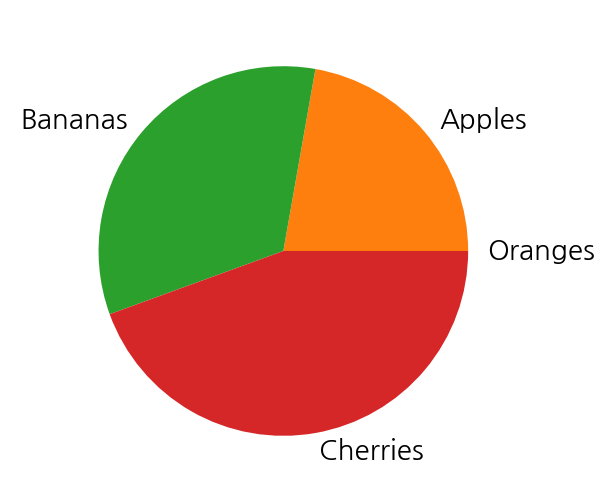

In [34]:
fruits = ["Oranges", "Apples", "Bananas", "Cherries"]
plt.pie([0, 20, 30, 40], labels = fruits);


In [42]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [43]:
mtc = data('mtcars')
mincars = mtc.iloc[:, : 4]
mincars.head()

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


In [46]:
print(mtc.columns[:4])
print(mtc.columns[:4]. to_list)

Index(['mpg', 'cyl', 'disp', 'hp'], dtype='object')
<bound method IndexOpsMixin.tolist of Index(['mpg', 'cyl', 'disp', 'hp'], dtype='object')>


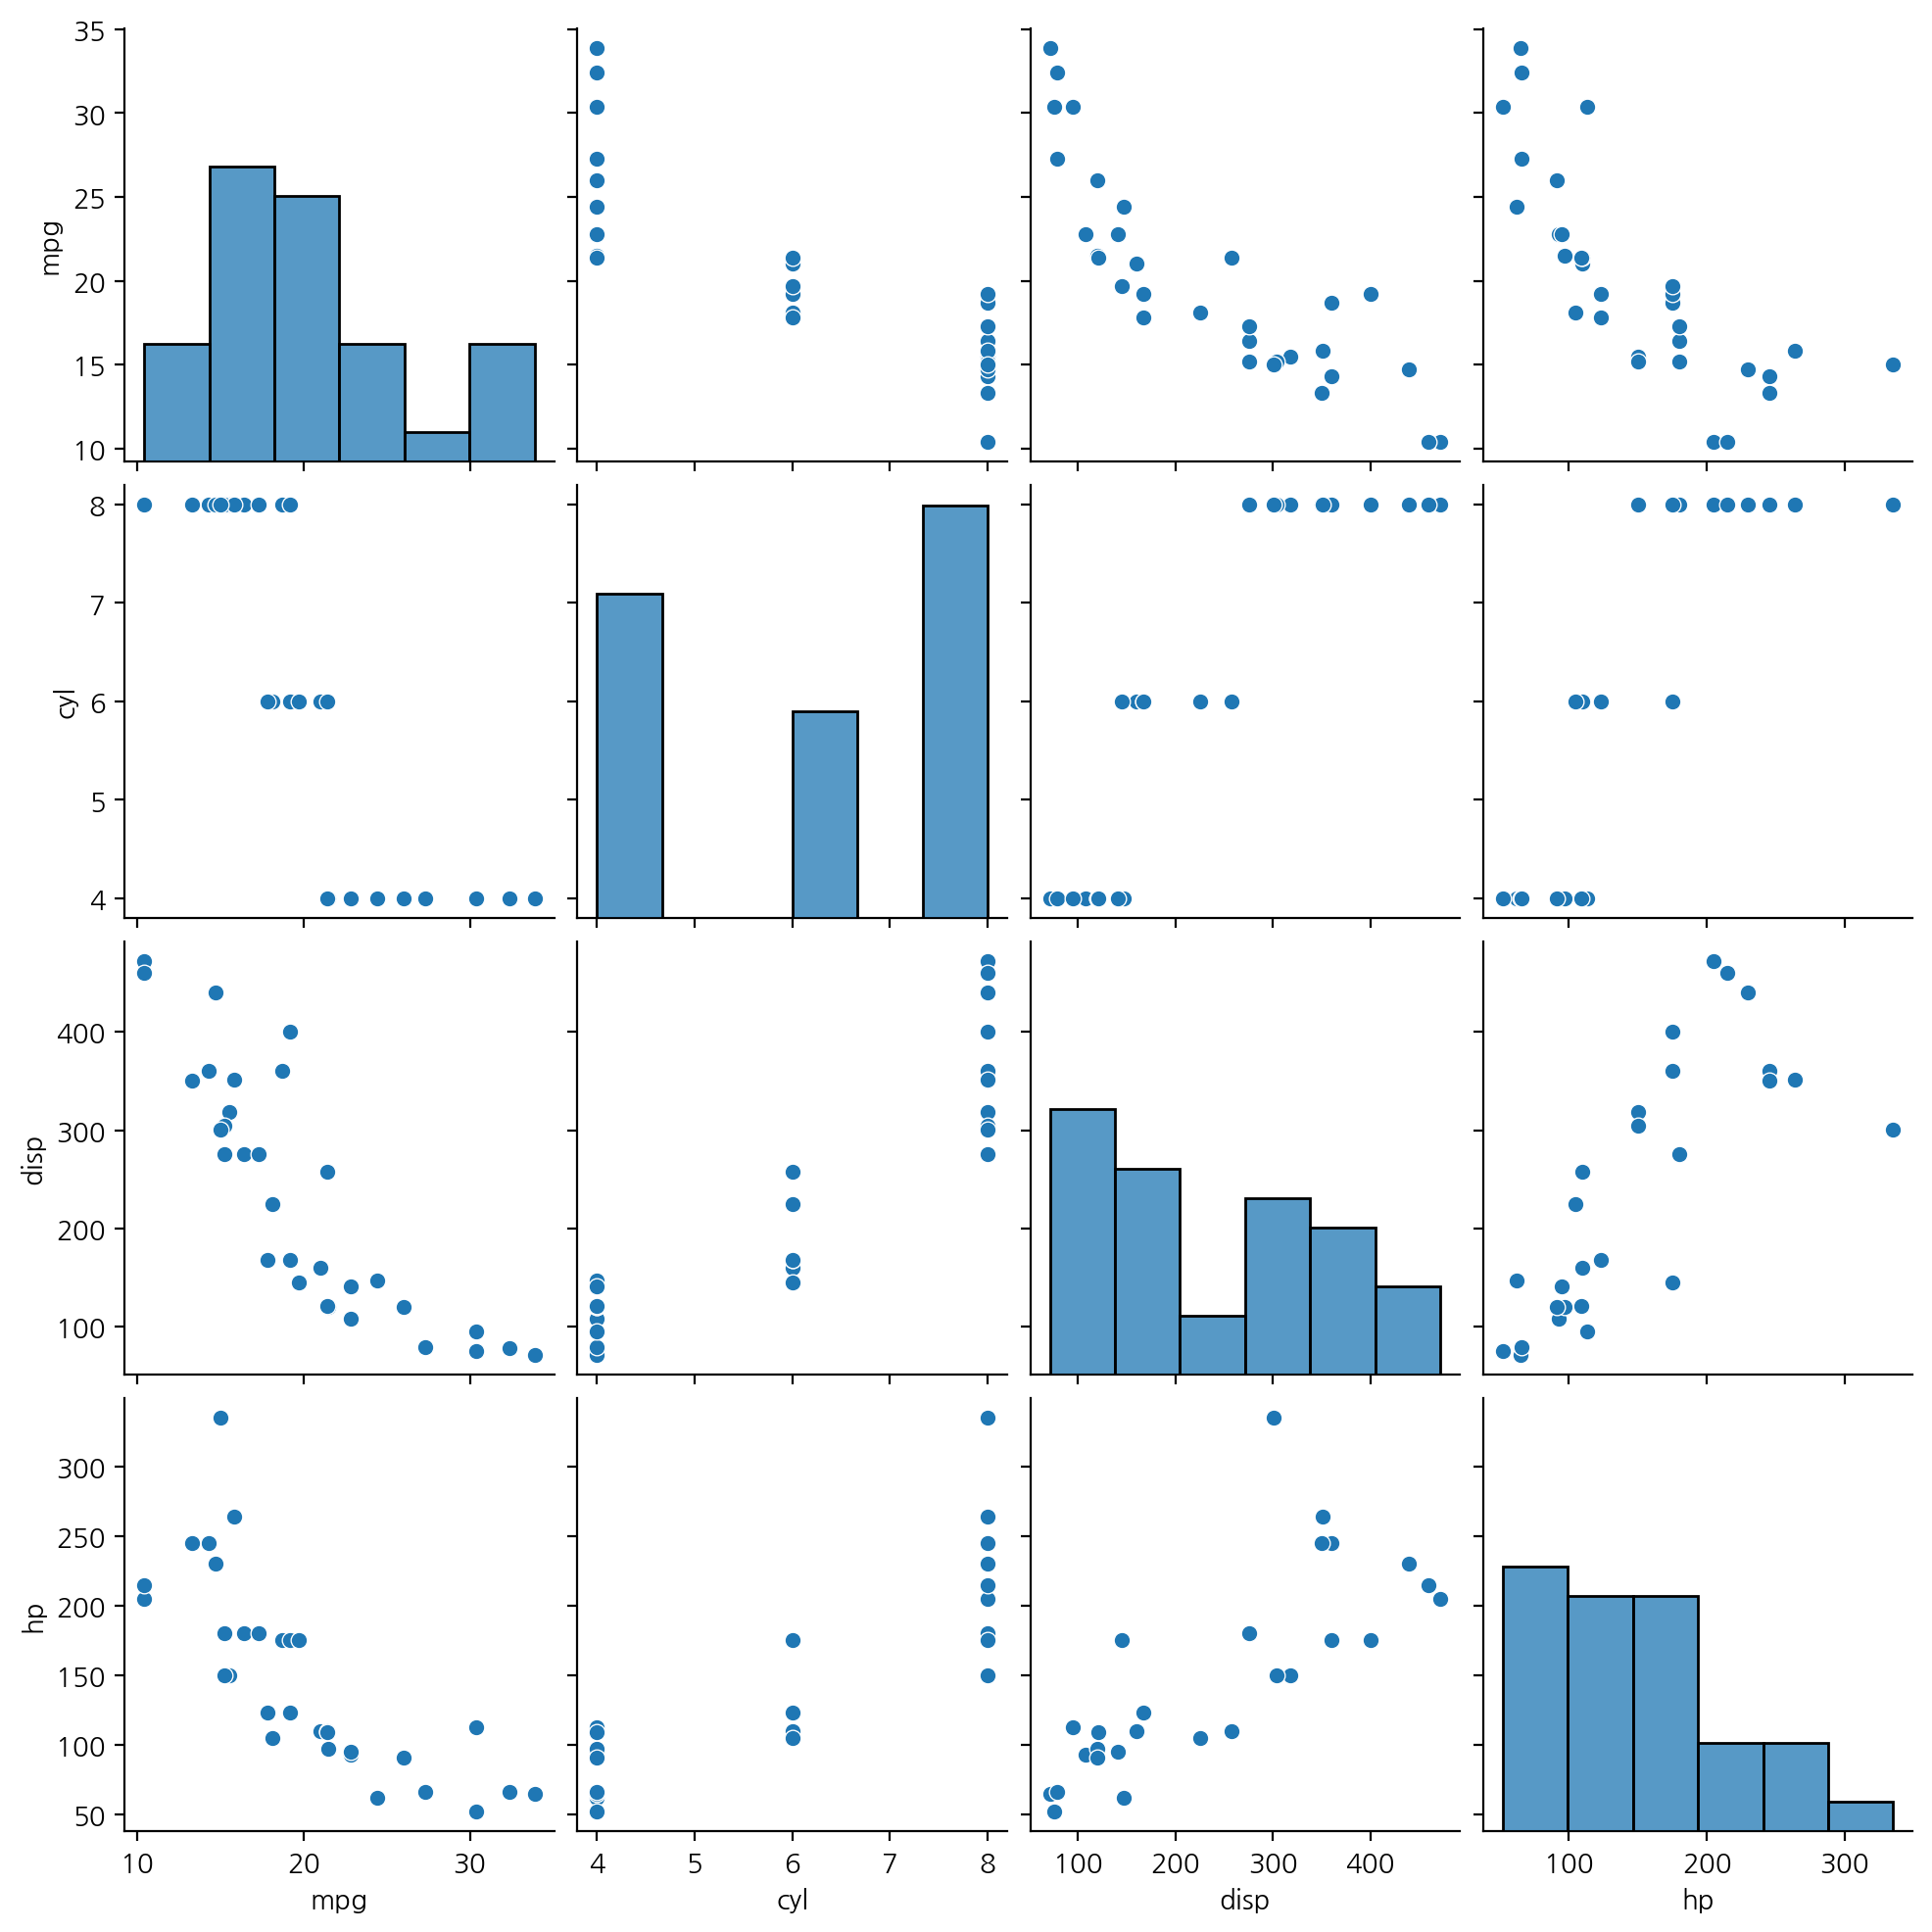

In [47]:
sns.pairplot(mincars)

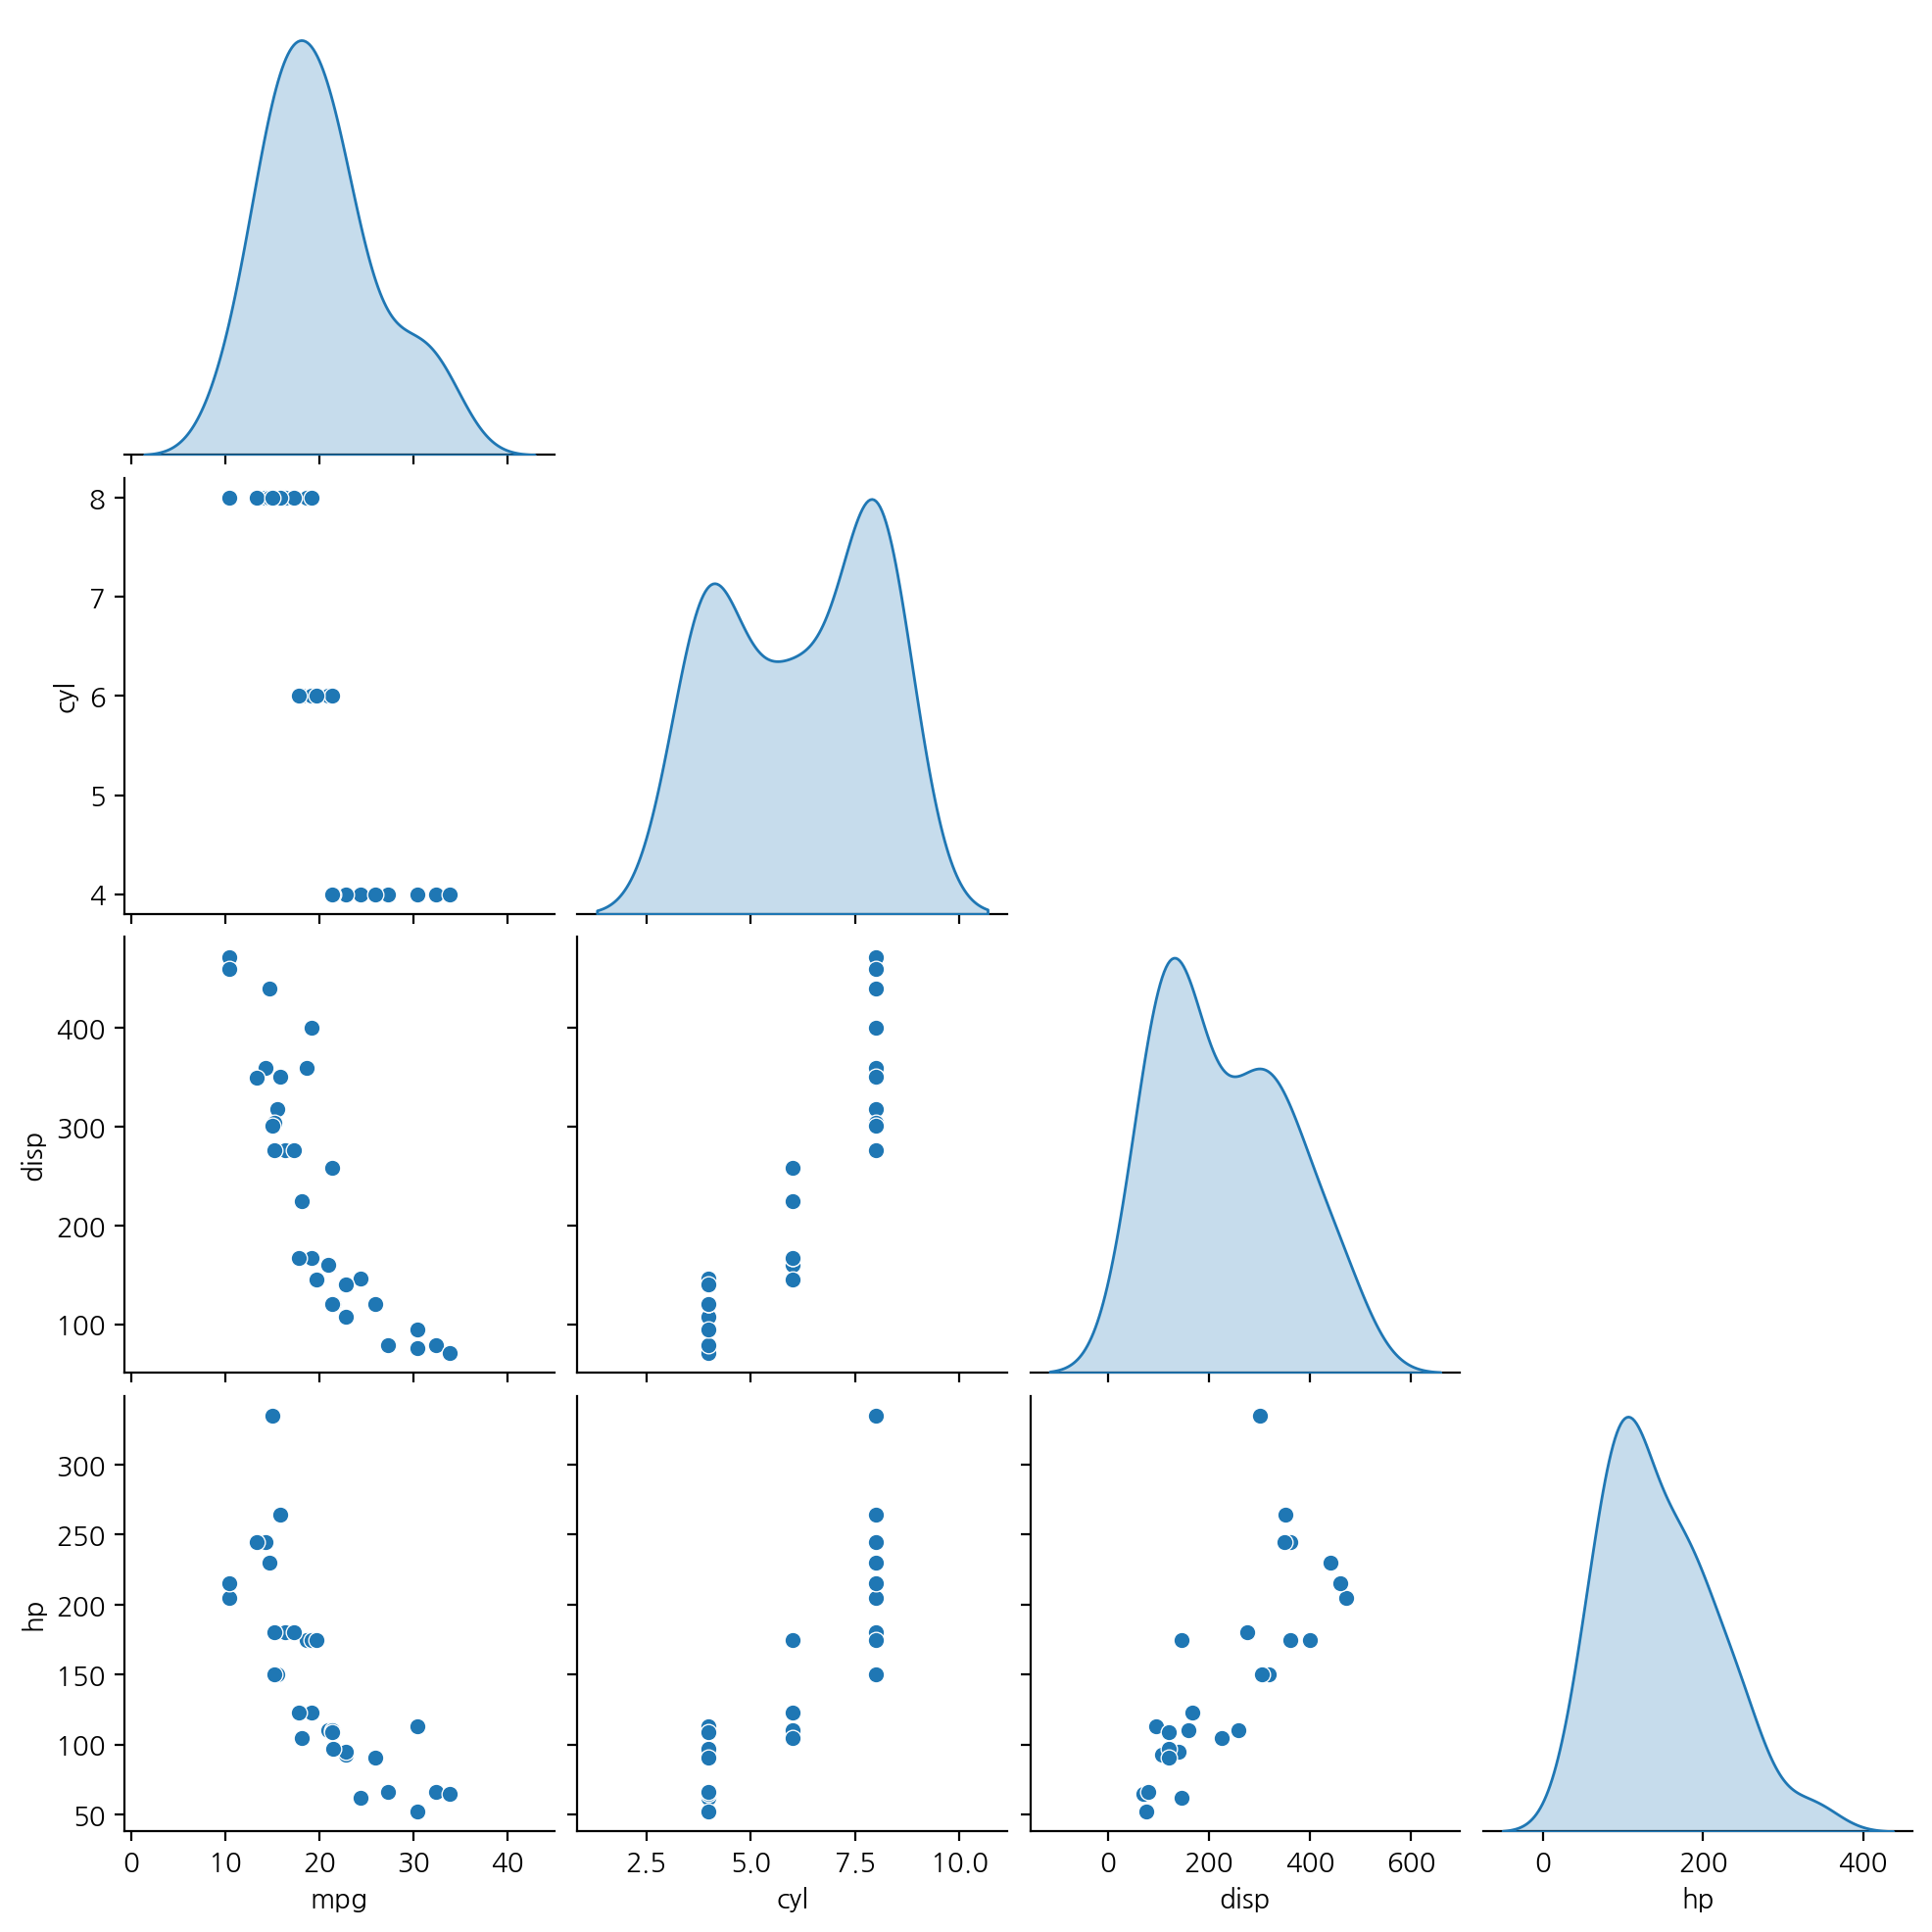

In [56]:
sns.pairplot(mincars, diag_kind='kde', corner=True);

In [51]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [53]:
pd.set_option('display.precision', 2)

In [52]:
import pandas as pd

pd.set_option('display.precision', 3)
corr_iris = iris[iris. columns[: -1].to_list()].corr()
corr_iris

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


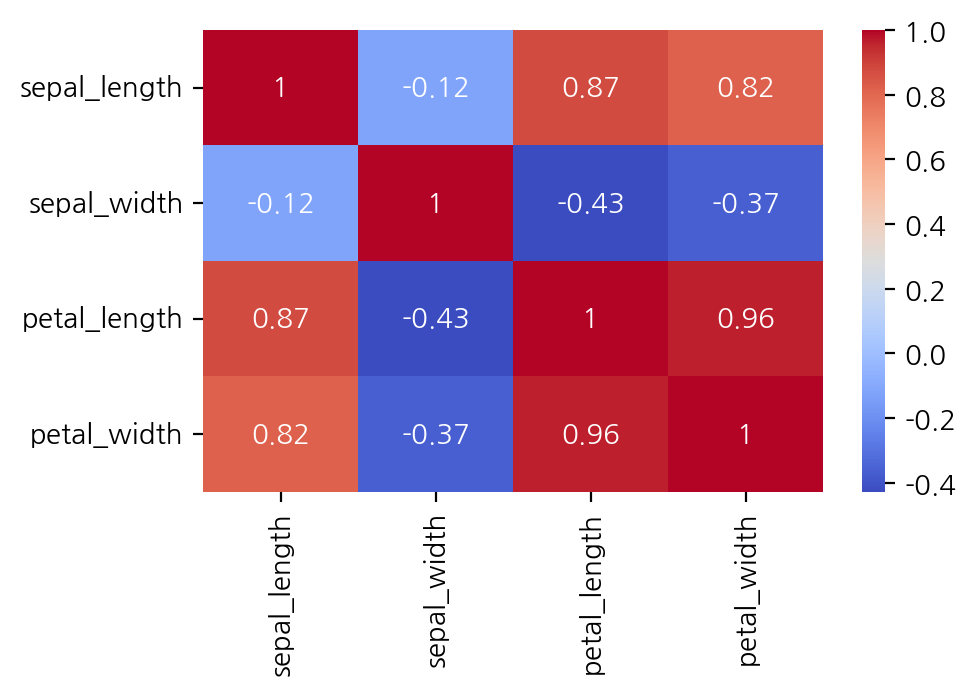

In [61]:
sns.heatmap(corr_iris, cmap = 'coolwarm', annot=True);

In [58]:
import numpy as np

mask = np.zeros_like(corr_iris)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [59]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [60]:
mask[np.triu_indices_from(mask)] = 1
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

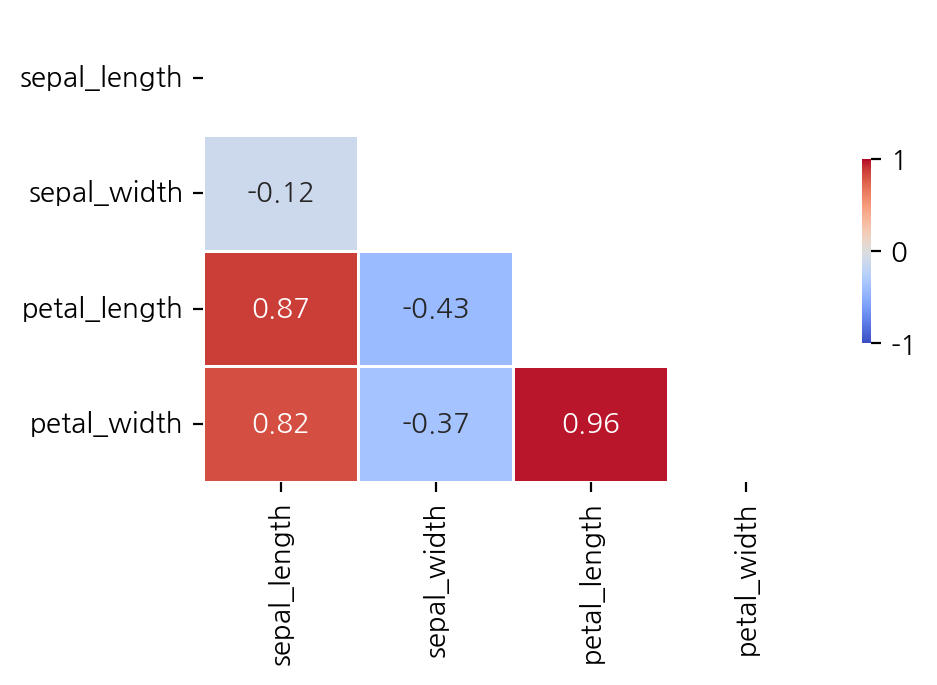

In [63]:
sns.heatmap(corr_iris, annot=True, cmap='coolwarm', mask=mask, annot_kws = {"size": 10}, vmin=-1, vmax=1, cbar_kws={'shrink': .4}, linewidths= .5);

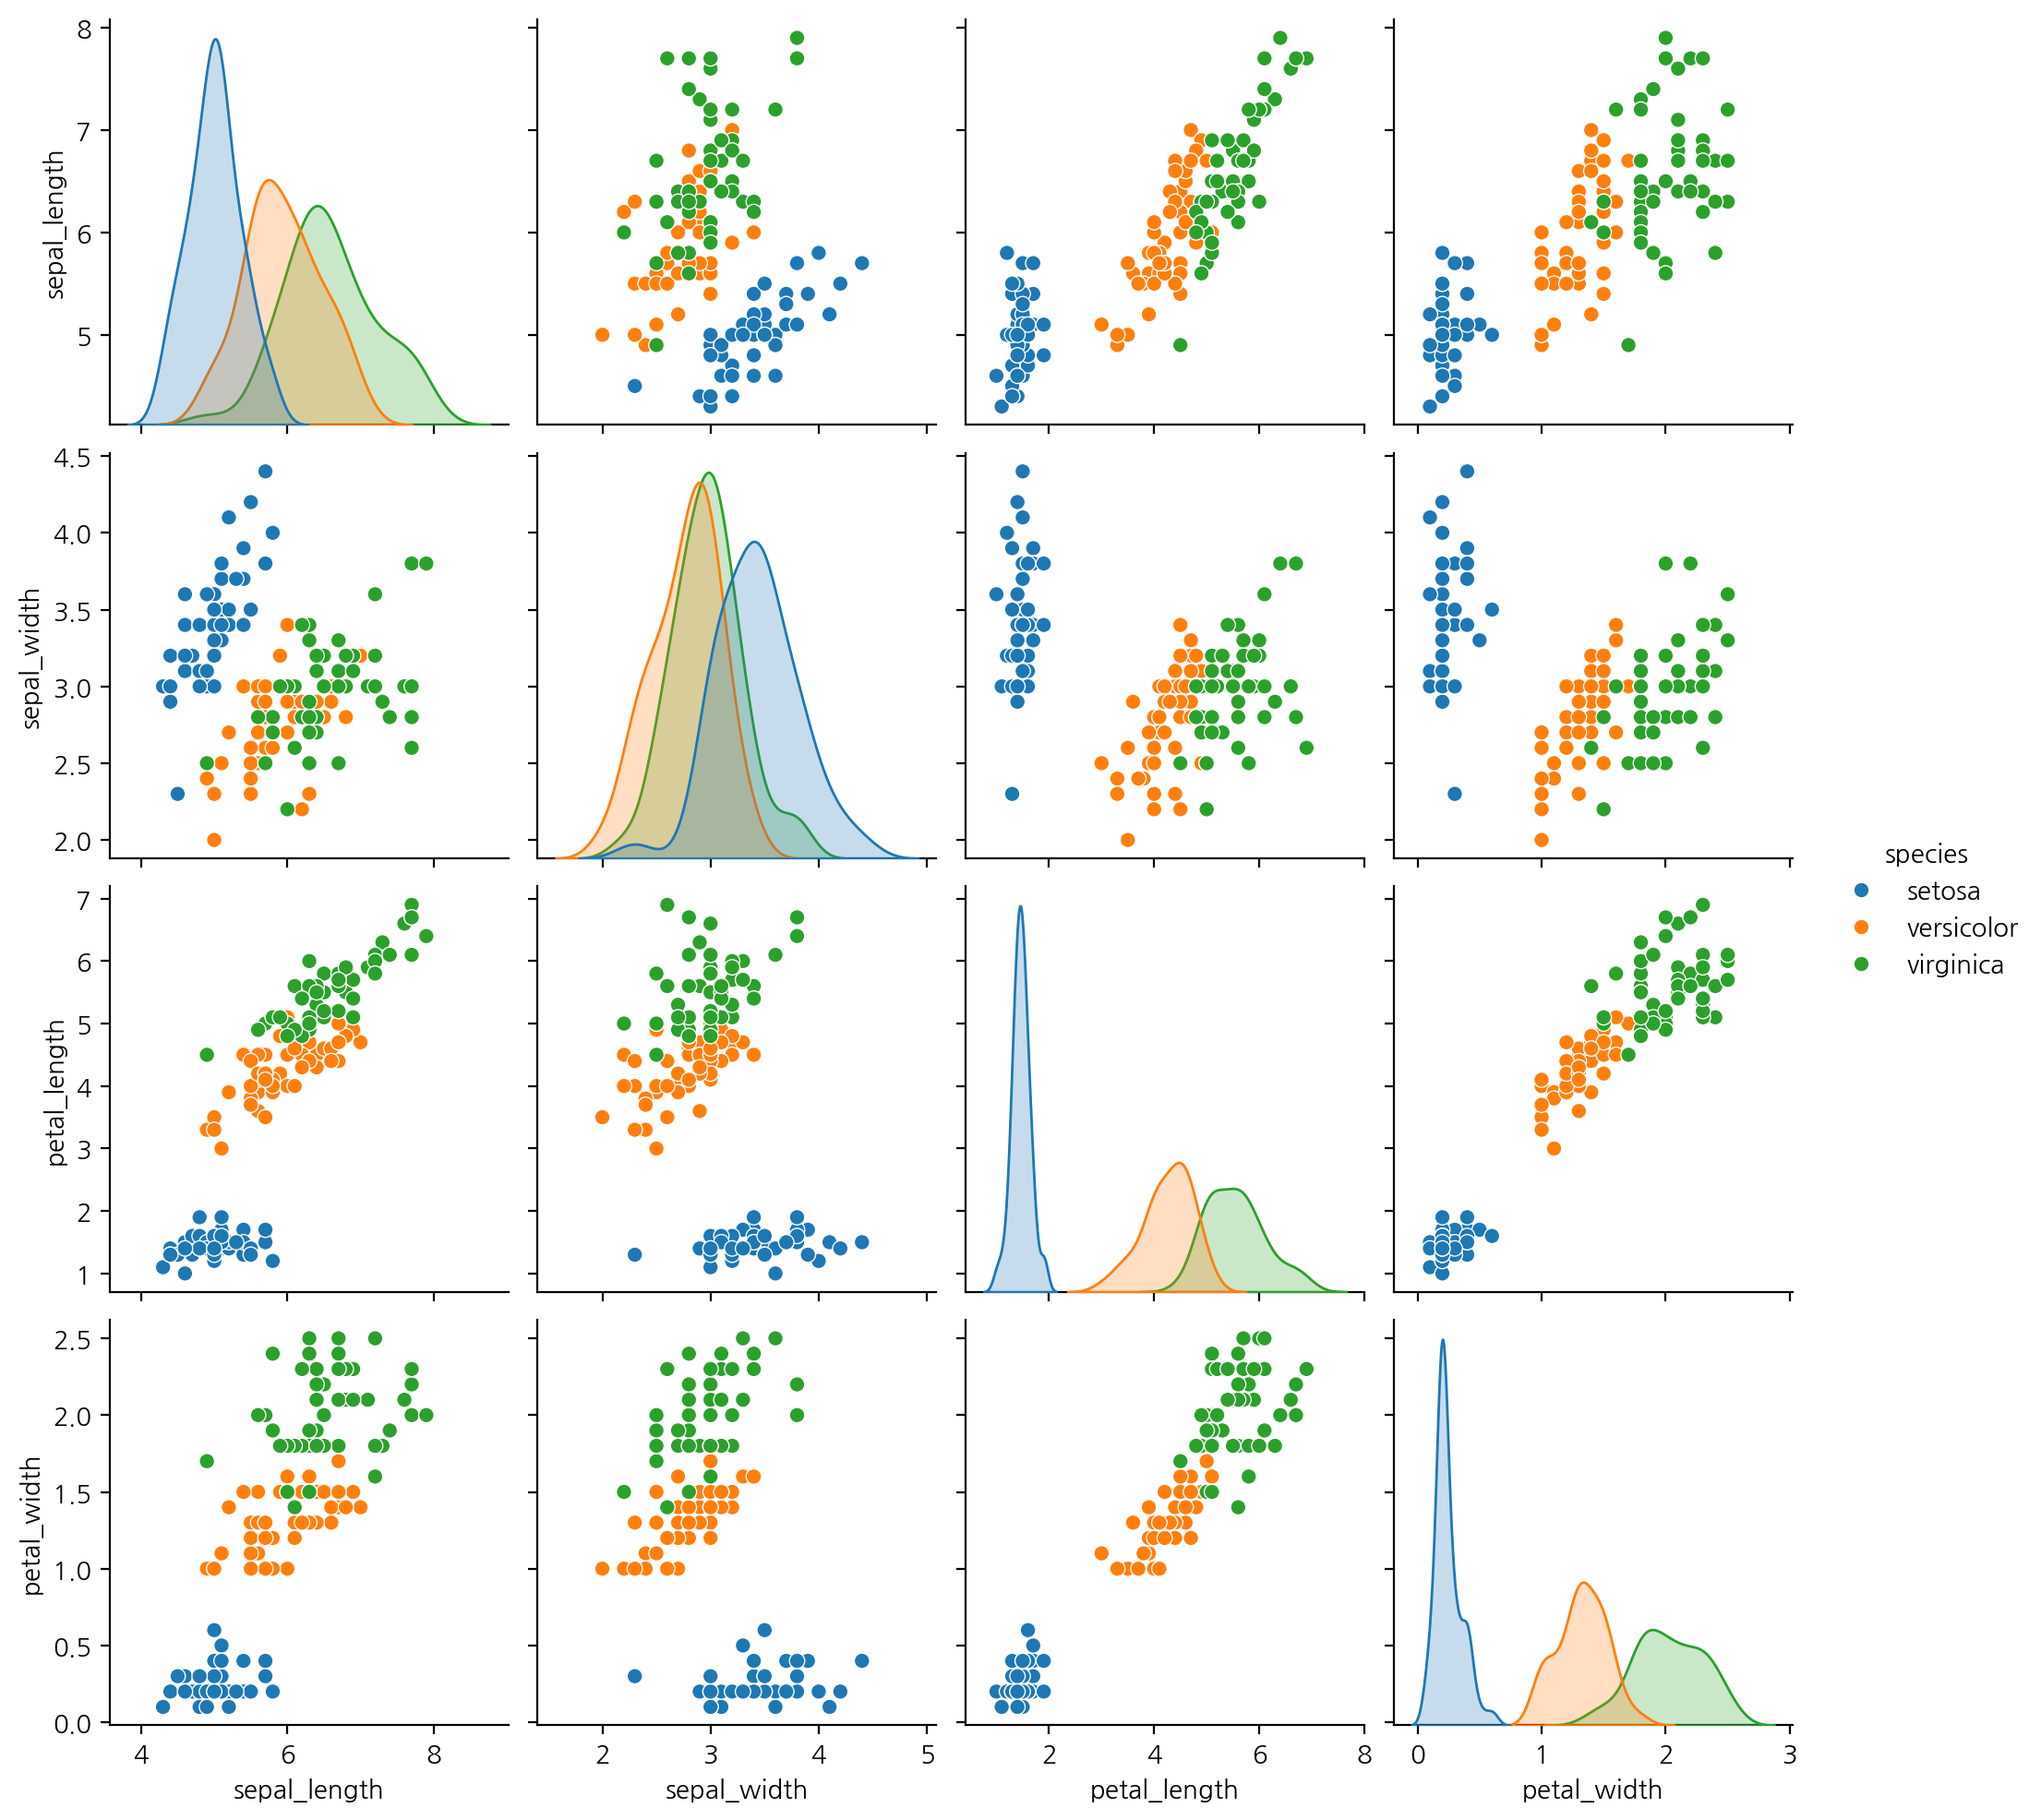

In [64]:
sns.pairplot(iris, hue='species')

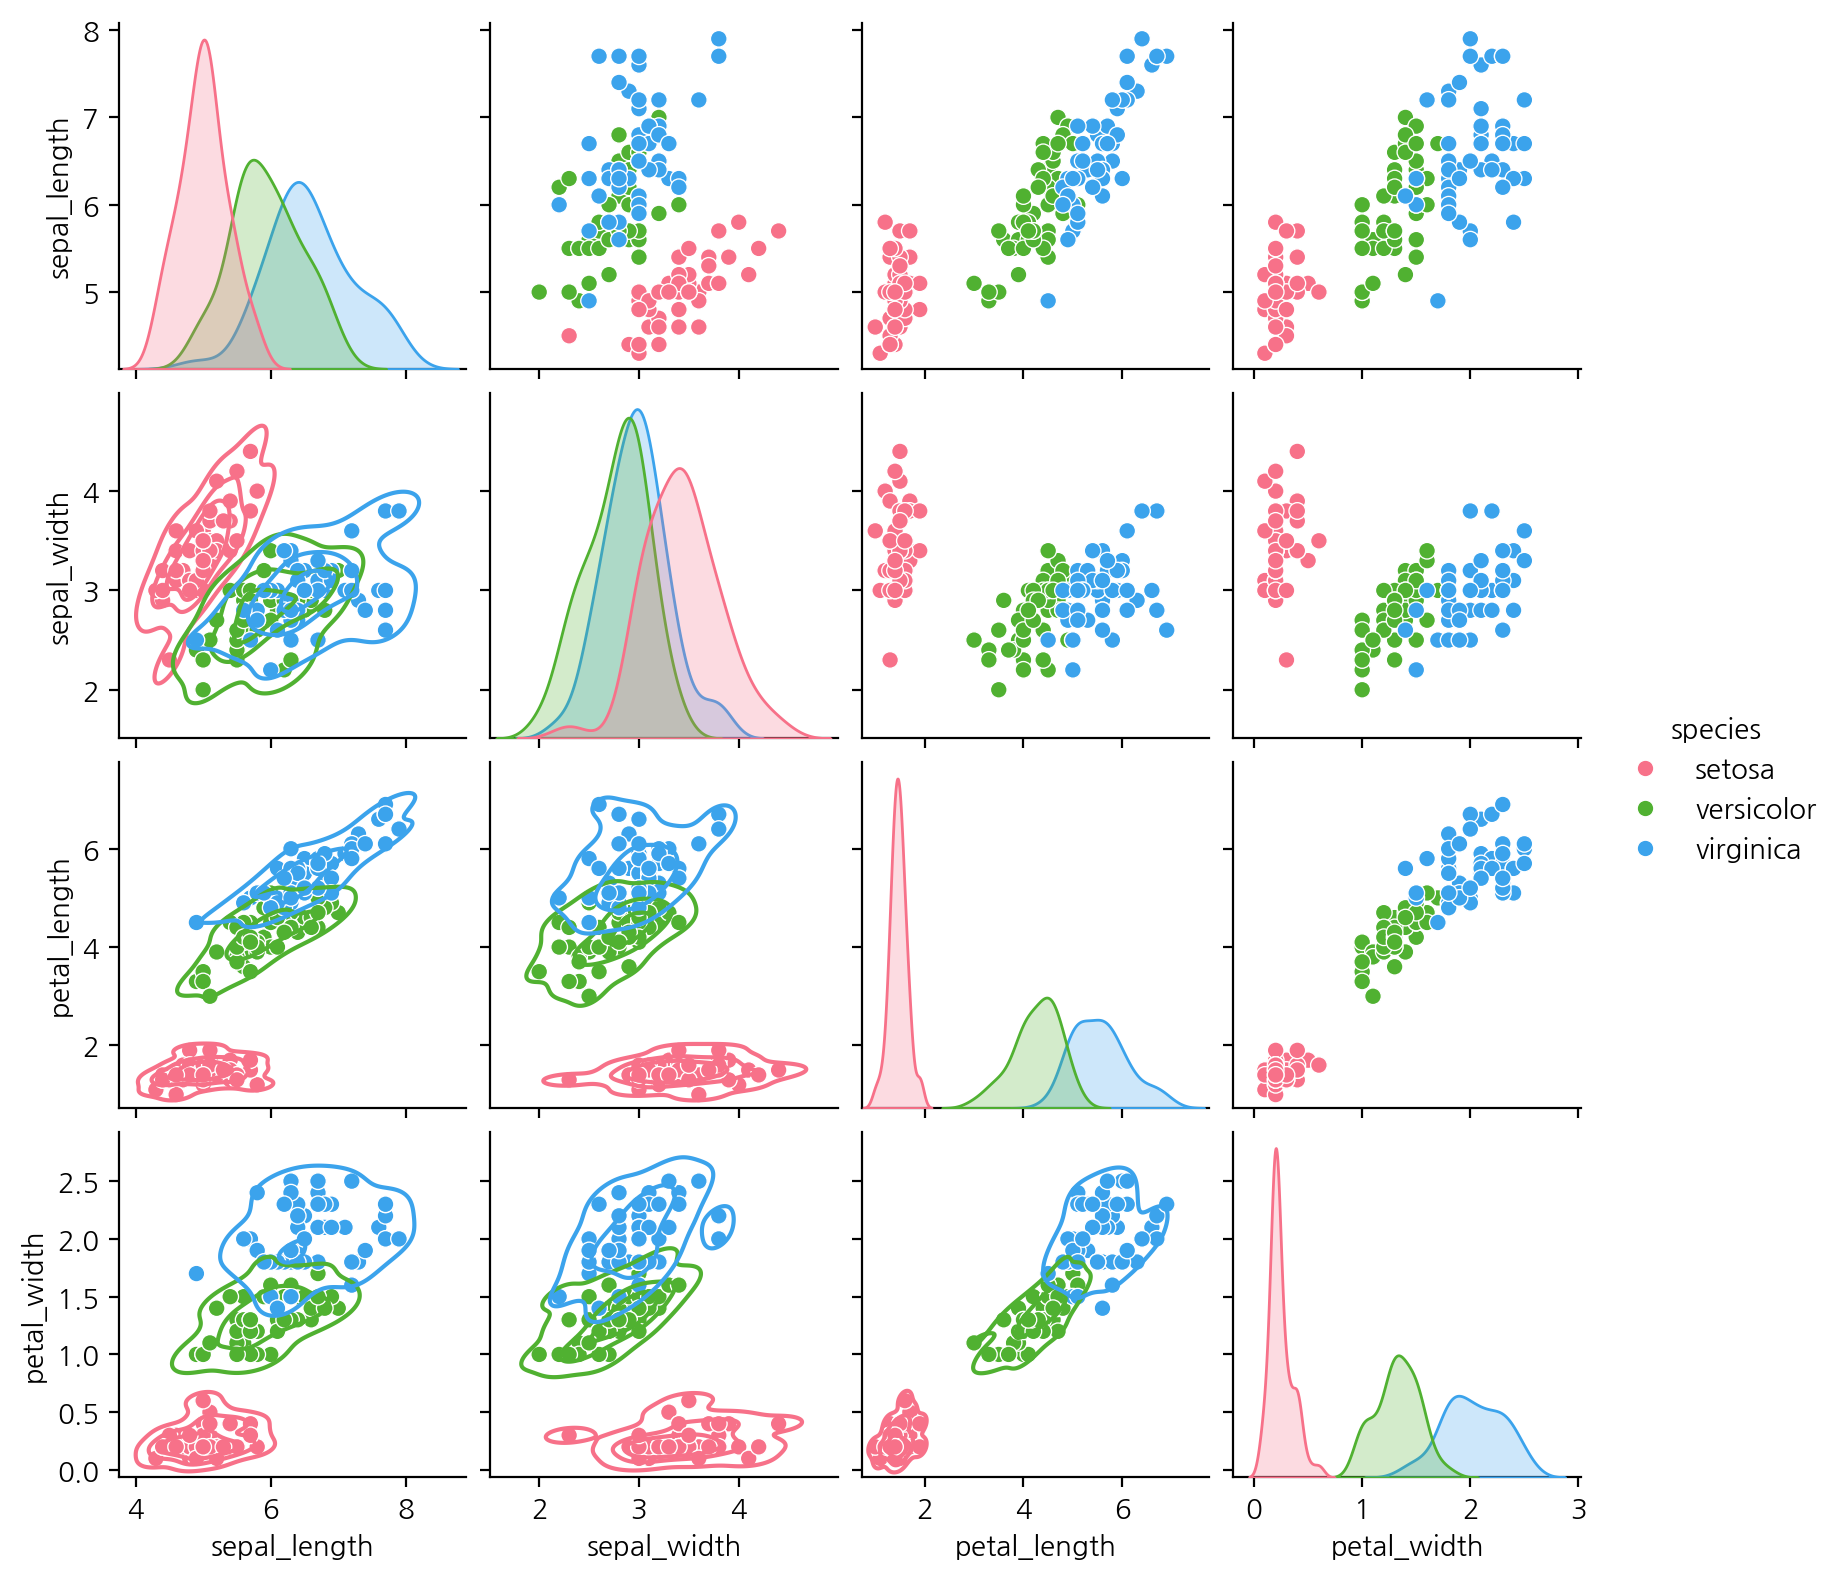

In [68]:
g = sns.pairplot(iris, hue="species", palette="husl", height=2.0);
g.map_lower(sns.kdeplot, levels=4, color=".2");

In [69]:
from pydataset import data
df = data('airquality')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 8.4 KB


In [70]:
df = data('airquality')
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 8.4 KB


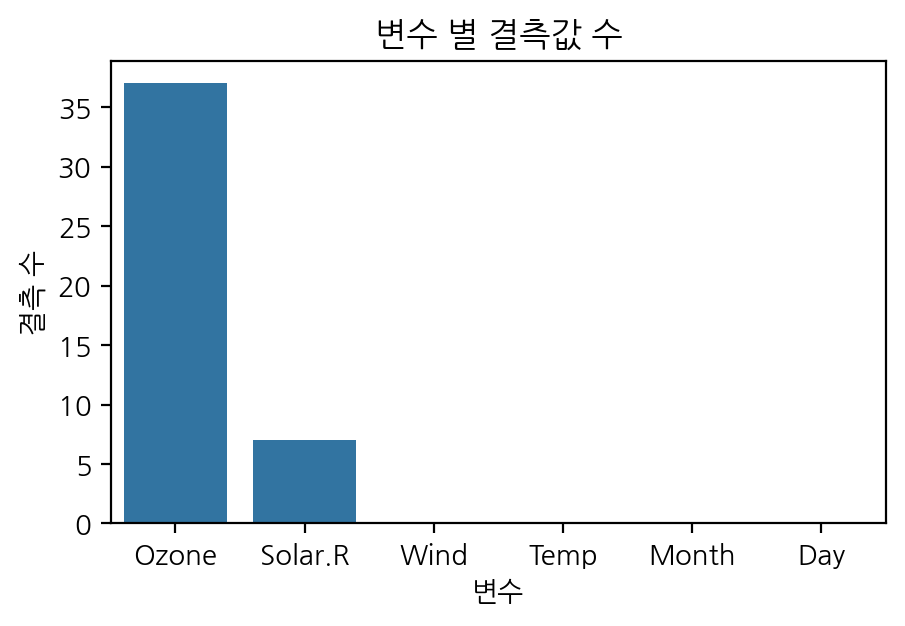

In [71]:
plt.title('변수 별 결측값 수')
sns.barplot(df.isnull().sum())
plt.ylabel('결측 수')
plt.xlabel('변수')
plt.show()